In [1]:
import numpy as np
import pandas as pd

**Load the Dataset**

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")

print(train_df.head())

         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10


In [4]:
print(train_df.shape)

(913000, 4)


In [6]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB
None


In [5]:
test_df = pd.read_csv('../data/raw/test.csv')

In [9]:
test_df.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      45000 non-null  int64 
 1   date    45000 non-null  object
 2   store   45000 non-null  int64 
 3   item    45000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ MB


**Convert the date properly**

In [11]:
train_df["date"] = pd.to_datetime(train_df["date"])

**Some basic checks**

In [12]:
print(train_df.isnull().sum())
print("Duplicates:", train_df.duplicated().sum())
print(train_df.describe())

date     0
store    0
item     0
sales    0
dtype: int64
Duplicates: 0
                                date          store           item  \
count                         913000  913000.000000  913000.000000   
mean   2015-07-02 11:59:59.999999744       5.500000      25.500000   
min              2013-01-01 00:00:00       1.000000       1.000000   
25%              2014-04-02 00:00:00       3.000000      13.000000   
50%              2015-07-02 12:00:00       5.500000      25.500000   
75%              2016-10-01 00:00:00       8.000000      38.000000   
max              2017-12-31 00:00:00      10.000000      50.000000   
std                              NaN       2.872283      14.430878   

               sales  
count  913000.000000  
mean       52.250287  
min         0.000000  
25%        30.000000  
50%        47.000000  
75%        70.000000  
max       231.000000  
std        28.801144  


**Adding some extra time features**

In [13]:
train_df["year"] = train_df["date"].dt.year
train_df["month"] = train_df["date"].dt.month
train_df["day"] = train_df["date"].dt.day
train_df["dayofweek"] = train_df["date"].dt.dayofweek
train_df["weekofyear"] = train_df["date"].dt.isocalendar().week

**Lets observe overall sales trend**

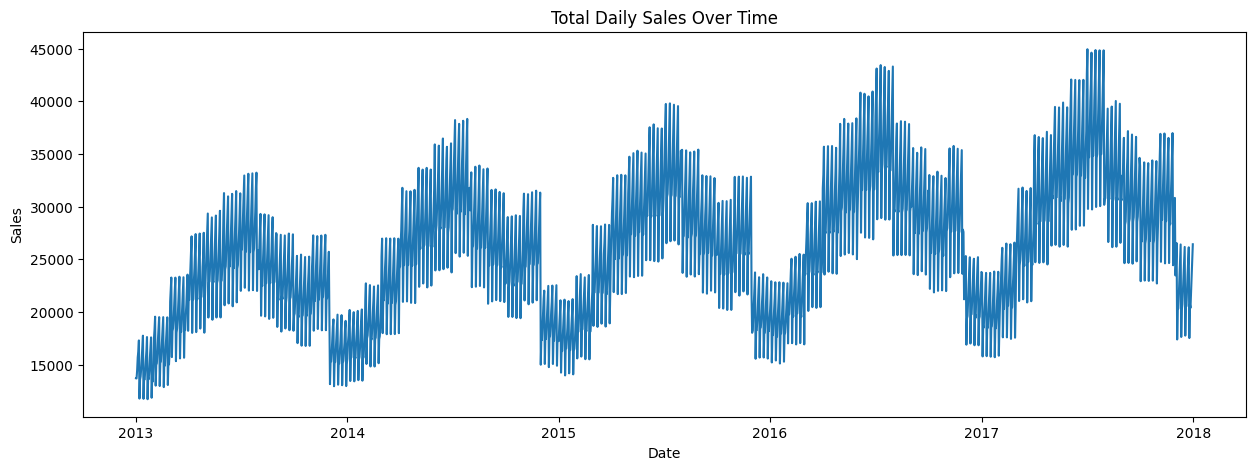

In [14]:
import matplotlib.pyplot as plt

daily_sales = train_df.groupby("date")["sales"].sum()

plt.figure(figsize=(15,5))
plt.plot(daily_sales)
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

The graph of total daily sales over time shows a clear upward trend from 2013 to 2017, indicating that overall demand has increased steadily over the years. It also exhibits strong repeating seasonal patterns, where sales rise and fall at regular intervals, suggesting yearly demand cycles. In addition, short-term fluctuations are visible, which may be caused by weekly patterns, promotions, or holidays.

**Monthly Seasonality**

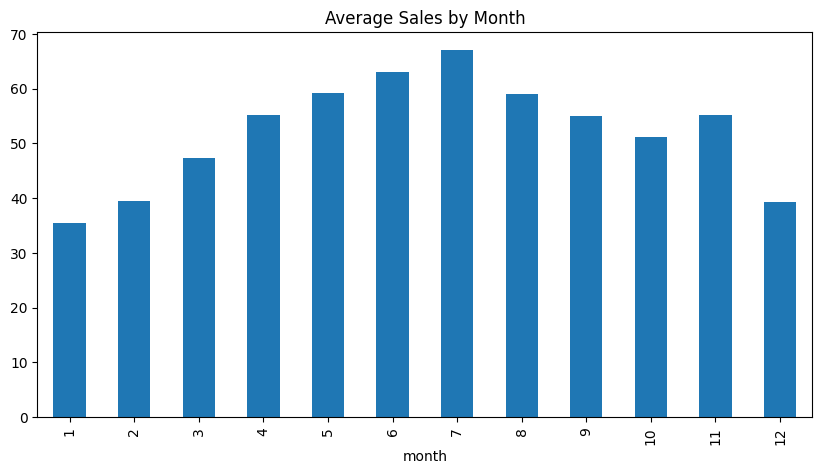

In [15]:
monthly = train_df.groupby("month")["sales"].mean()

monthly.plot(kind="bar", figsize=(10,5))
plt.title("Average Sales by Month")
plt.show()

The bar chart shows the average sales for each month, highlighting clear seasonal patterns in demand. Sales gradually increase from January and reach their peak in July, indicating stronger customer activity during the middle of the year. After July, average sales begin to decline, with lower values observed toward the end of the year, especially in December. This monthly variation suggests that seasonality plays an important role in sales behavior.

**Effect of weekday**

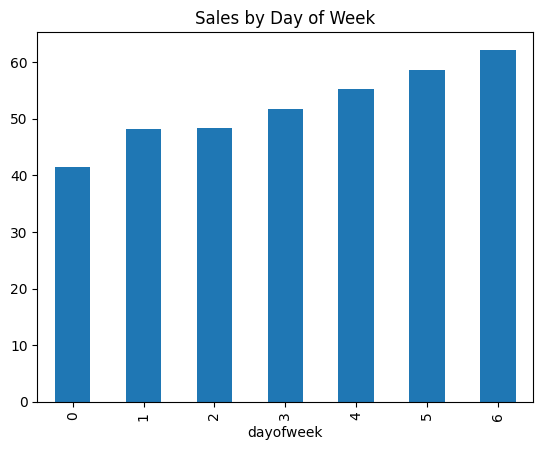

In [16]:
weekday = train_df.groupby("dayofweek")["sales"].mean()

weekday.plot(kind="bar")
plt.title("Sales by Day of Week")
plt.show()

The chart shows average sales by day of the week, indicating noticeable weekly sales patterns. Sales are lowest at the beginning of the week and gradually increase as the week progresses. The highest sales are observed on day 6, suggesting stronger customer demand during weekends. This pattern implies that weekly seasonality influences sales performance, and incorporating day-of-week effects can improve forecasting accuracy.

**Store performance**

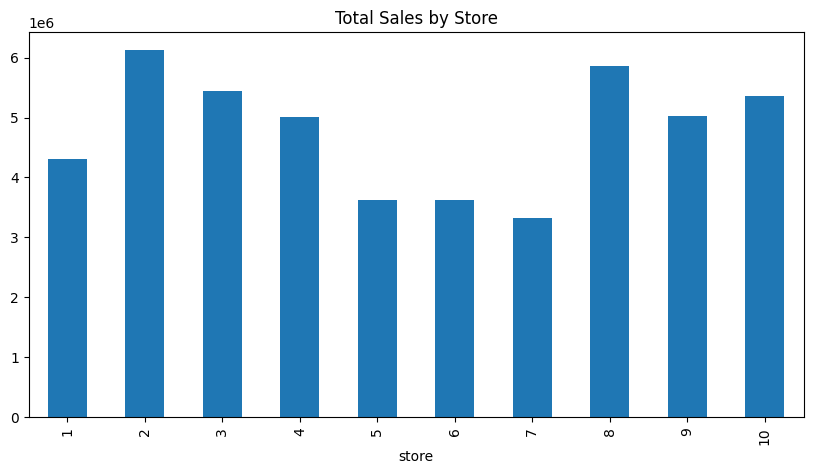

In [17]:
store_sales = train_df.groupby("store")["sales"].sum()

store_sales.plot(kind="bar", figsize=(10,5))
plt.title("Total Sales by Store")
plt.show()

The bar chart displays total sales across different stores, showing significant variation in performance. Store 2 has the highest total sales, followed closely by Store 8, while Stores 5, 6, and 7 record comparatively lower sales. Most other stores show moderate to strong performance, indicating differences in customer demand, location, or store capacity. This variation suggests that store-specific factors are important and should be included as features in the forecasting model.

**Item performance**

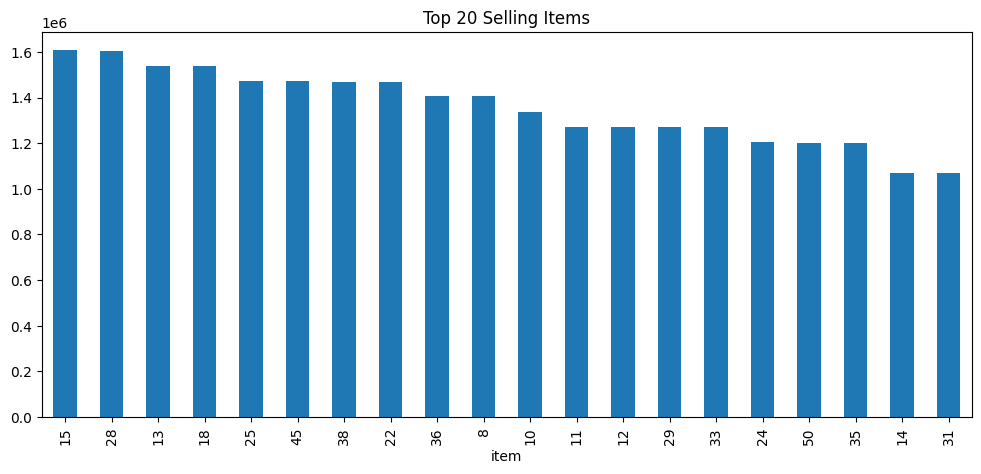

In [18]:
top_items = train_df.groupby("item")["sales"].sum().sort_values(ascending=False).head(20)

top_items.plot(kind="bar", figsize=(12,5))
plt.title("Top 20 Selling Items")
plt.show()

The chart presents the top 20 selling items based on total sales, highlighting the best-performing products in the dataset. Items 15 and 28 have the highest sales, followed closely by items 13 and 18. While sales differ across items, the gap between the top products is relatively moderate, indicating consistent demand among several leading items. Identifying these high-performing items is useful for inventory planning, promotions, and improving demand forecasting accuracy.

**Store vs Month Heatmap**

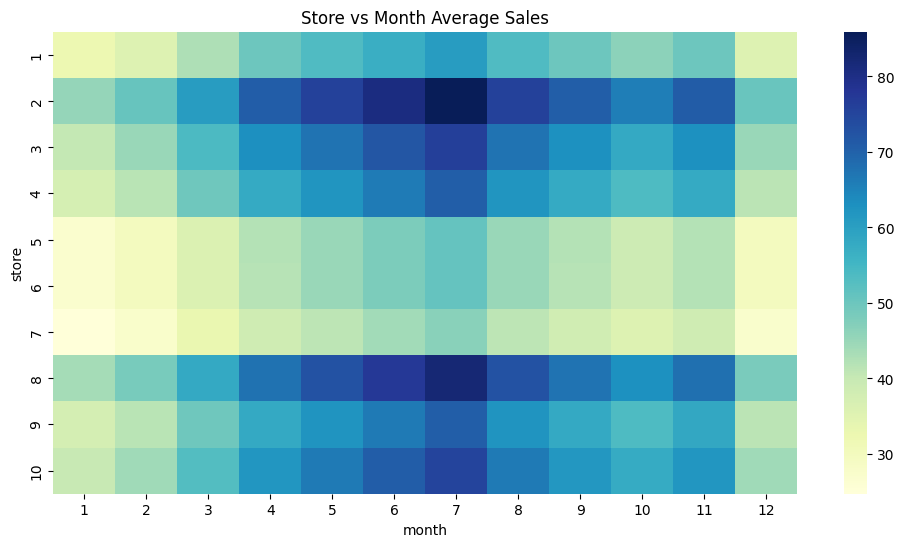

In [19]:
import seaborn as sns

pivot = train_df.pivot_table(values="sales", index="store", columns="month", aggfunc="mean")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Store vs Month Average Sales")
plt.show()

The heatmap illustrates average sales across stores and months, revealing both store-wise and seasonal demand patterns. Sales generally increase from the beginning of the year and peak around the middle months, especially June and July, before declining toward the year end. Stores 2 and 8 consistently show the highest sales across most months, while Stores 5, 6, and 7 have comparatively lower performance. This pattern indicates that both store location and seasonal trends strongly influence sales, making them important factors for demand forecasting models.